# Task 4 — Network Analysis

The grid modelled as a graph: substations are nodes, lines are edges. The graph is
**undirected** because AC power flows either way along a line depending on system
conditions — a line has no fixed origin and destination the way a scheduled flight
does.

One interpretation rule for everything below: these are **structural** measures.
Degree and betweenness say things about the shape of the network, not about
electrical load, voltage stability or protection behaviour. Wherever a substation is
called "critical" in this notebook, it means *topologically* critical — a claim about
connectivity, offered as a proxy for where reliability attention might start, and no
more than that.

In [1]:
import sys

sys.path.append("../src")

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns

import griddata

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

data, _ = griddata.clean(griddata.load_raw())
G = griddata.build_graph(data)

OUT = "../outputs"
print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

44 nodes, 55 edges


## 1. Components: one grid, plus two disconnected stations

44 nodes because `build_graph` adds every substation before adding edges — the two
stations with no lines (Conakry Hub, Savelugu) stay visible as isolates instead of
silently vanishing, which is what happens if the graph is built straight from the
edge list (and why the brief's sample run reports 42).

For the metric calculations we work on the **main component**: path-based measures
like closeness and betweenness are undefined or misleading across disconnected
pieces.

In [2]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
print(f"components: {[len(c) for c in components]}")

main = G.subgraph(components[0]).copy()
print(f"main component: {main.number_of_nodes()} nodes, {main.number_of_edges()} edges")

components: [42, 1, 1]
main component: 42 nodes, 55 edges


## 2. Whole-network measures

In [3]:
overview = pd.Series({
    "Nodes (main component)": main.number_of_nodes(),
    "Edges": main.number_of_edges(),
    "Density": round(nx.density(main), 4),
    "Diameter (hops)": nx.diameter(main),
    "Average shortest path (hops)": round(nx.average_shortest_path_length(main), 2),
    "Average clustering coefficient": round(nx.average_clustering(main), 3),
    "Global efficiency": round(nx.global_efficiency(main), 3),
})
overview

Nodes (main component)            42.0000
Edges                             55.0000
Density                            0.0639
Diameter (hops)                   14.0000
Average shortest path (hops)       5.4100
Average clustering coefficient     0.3840
Global efficiency                  0.2680
dtype: float64

Reading these together: any substation reaches any other in a handful of hops on
average, with density under 10% — a sparse network held together by a small number
of connector nodes. Which nodes, exactly, is what centrality answers.

## 3. Centrality: four different definitions of "important"

- **Degree** — how many lines terminate here (local hub).
- **Betweenness** — how often the node sits on shortest paths between others
  (corridor/broker: remove it and traffic must detour).
- **Closeness** — average distance to everywhere else (how central to the whole map).
- **PageRank** — importance weighted by the importance of neighbours.

Computed on the main component; hop-based rather than km-weighted, since the
question is about connection structure, not travel distance.

In [4]:
centrality = pd.DataFrame({
    "Degree": dict(main.degree()),
    "Degree centrality": nx.degree_centrality(main),
    "Betweenness": nx.betweenness_centrality(main),
    "Closeness": nx.closeness_centrality(main),
    "PageRank": nx.pagerank(main),
    "Clustering": nx.clustering(main),
}).round(4)
centrality["Region"] = pd.Series(nx.get_node_attributes(main, "region"))
centrality = centrality.sort_values("Betweenness", ascending=False)
centrality.head(10)

,Degree,Degree centrality,Betweenness,Closeness,PageRank,Clustering,Region
Cape Coast Substation,5,0.1220,0.5787,0.2770,0.0383,0.2000,Central
Takoradi Substation,4,0.0976,0.5683,0.2733,0.0306,0.1667,Western
Kumasi Central Substation,5,0.1220,0.5512,0.2562,0.0396,0.1000,Ashanti
Koforidua Substation,4,0.0976,0.5488,0.2662,0.0318,0.1667,Eastern
Ho Substation,4,0.0976,0.4805,0.2440,0.0358,0.1667,Volta
Sunyani Substation,3,0.0732,0.3683,0.2158,0.0309,0.0000,Bono
Achimota Substation,4,0.0976,0.3236,0.2228,0.0289,0.3333,Greater Accra
Tamale Substation,3,0.0732,0.2622,0.1881,0.0335,0.0000,Northern
Bolgatanga Substation,4,0.0976,0.1866,0.1640,0.0473,0.0000,Upper East
Tema Substation,4,0.0976,0.1528,0.1916,0.0304,0.3333,Greater Accra


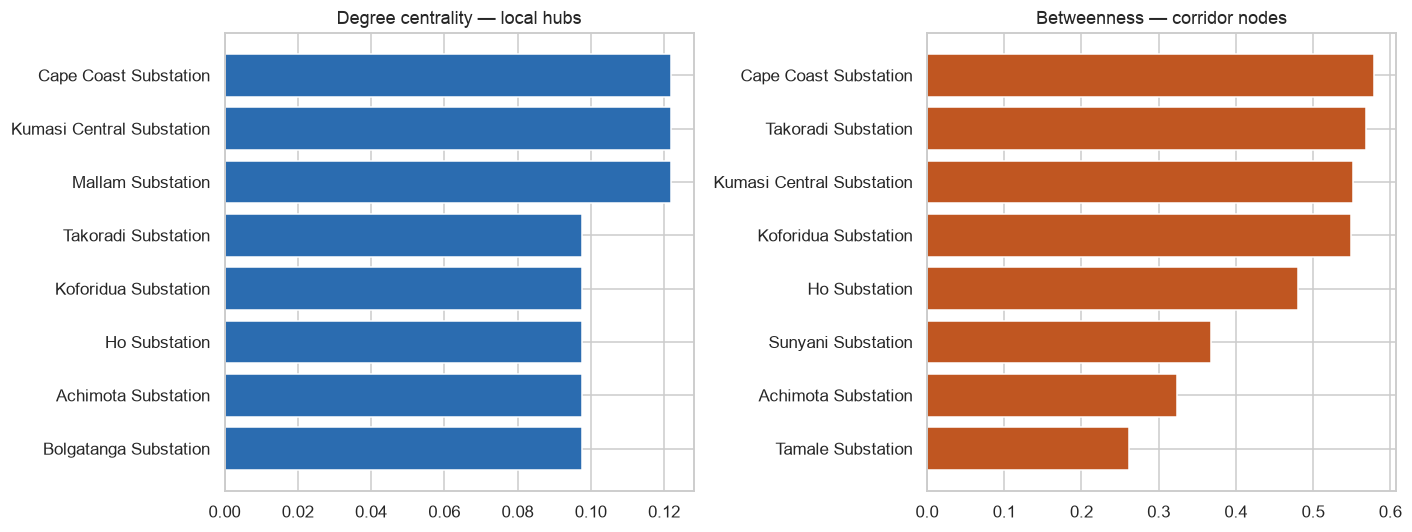

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_deg = centrality.nlargest(8, "Degree centrality")
axes[0].barh(top_deg.index, top_deg["Degree centrality"], color="#2b6cb0")
axes[0].invert_yaxis()
axes[0].set_title("Degree centrality — local hubs")

top_bet = centrality.nlargest(8, "Betweenness")
axes[1].barh(top_bet.index, top_bet["Betweenness"], color="#c05621")
axes[1].invert_yaxis()
axes[1].set_title("Betweenness — corridor nodes")

fig.tight_layout()
fig.savefig(f"{OUT}/n1_centrality_rankings.png", bbox_inches="tight")

The two rankings disagree, and the disagreement is the finding:

- **Degree** crowns the EDA's Q7 answer — Mallam, Kumasi Central, Cape Coast
  (5 connections each). Local hubs inside dense regional clusters.
- **Betweenness** promotes the **backbone chain** — the stations that everything
  east–west or north–south must pass through.

Operationally that distinction is exactly why one metric isn't enough: a high-degree
station failing inconveniences a neighbourhood; a high-betweenness station failing
forces re-routing across half the network — *if* an alternative route exists at all,
which is the N-1 question below.

## 4. Communities: does the graph rediscover the regions?

Greedy modularity on the main component. If community detection roughly reproduces
the administrative regions, regional boundaries are real network boundaries too, not
just lines on a map.

In [6]:
communities = list(nx.community.greedy_modularity_communities(main))
print(f"{len(communities)} communities, sizes {[len(c) for c in communities]}")
print(f"modularity: {nx.community.modularity(main, communities):.3f}")

membership = {}
for i, community in enumerate(communities):
    for node in community:
        membership[node] = i

crosstab = pd.crosstab(
    pd.Series(membership, name="Community"),
    pd.Series(nx.get_node_attributes(main, "region"), name="Region"),
)
crosstab

8 communities, sizes [10, 7, 6, 4, 4, 4, 4, 3]
modularity: 0.730


Region,Ashanti,Benin,Bono,Burkina Faso,Burkina Faso border,Central,Cote d'Ivoire,Cote d'Ivoire border,Eastern,Greater Accra,Northern,Togo,Togo border,Upper East,Upper West,Volta,Western
Community,,,,,,,,,,,,,,,,,
0,0,0,3,1,1,0,0,0,0,0,2,0,0,2,1,0,0
1,5,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
4,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0
7,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0


The communities come out as unions of adjacent regions rather than one community per
region — regional clusters plus the corridors that join them. Cross-border stations
join whichever Ghanaian cluster they attach to, confirming that the WAPP links are
extensions of regional clusters rather than a separate international layer.

## 5. Bridges: single points of failure among the *lines*

A bridge is an edge whose removal disconnects part of the network. The merged-data
notebook predicted every inter-regional corridor would be one, since each region
pair is joined by exactly one line.

In [7]:
bridges = list(nx.bridges(main))
bridge_df = pd.DataFrame(bridges, columns=["End A", "End B"])
bridge_df["Regions"] = bridge_df.apply(
    lambda r: f"{main.nodes[r['End A']]['region']} - {main.nodes[r['End B']]['region']}", axis=1
)
bridge_df["Inter-regional"] = bridge_df.apply(
    lambda r: main.nodes[r["End A"]]["region"] != main.nodes[r["End B"]]["region"], axis=1
)
print(f"{len(bridge_df)} bridges, {int(bridge_df['Inter-regional'].sum())} of them inter-regional")
bridge_df

21 bridges, 16 of them inter-regional


,End A,End B,Regions,Inter-regional
0,Achimota Substation,Kumasi Central Substation,Greater Accra - Ashanti,True
1,Tema Substation,Aflao Border Station,Greater Accra - Togo border,True
2,Kumasi Central Substation,Takoradi Substation,Ashanti - Western,True
3,Kumasi Central Substation,Elubo Border Station,Ashanti - Cote d'Ivoire border,True
4,Takoradi Substation,Cape Coast Substation,Western - Central,True
5,Cape Coast Substation,Koforidua Substation,Central - Eastern,True
6,Koforidua Substation,Ho Substation,Eastern - Volta,True
7,Ho Substation,Sunyani Substation,Volta - Bono,True
8,Hohoe Substation,Sogakope Substation,Volta - Volta,False
9,Sunyani Substation,Techiman Substation,Bono - Bono,False


As predicted, the backbone and border links dominate the bridge list. Inside
regions, meshing gives alternative routes, so fewer intra-regional lines are
bridges. Between regions there is no redundancy at all — every corridor is a
bridge. In a real grid this is the strongest argument this analysis could produce
for where to build the next line.

## 6. Shortest paths between major substations

In [8]:
pairs = [
    ("Achimota Substation", "Tamale Substation"),
    ("Tema Substation", "Takoradi Substation"),
    ("Kumasi Central Substation", "Bolgatanga Substation"),
    ("Tema Substation", "Lome Transmission Hub"),
]
for a, b in pairs:
    path = nx.shortest_path(main, a, b)
    print(f"{a}  ->  {b}   ({len(path) - 1} hops)")
    print("   " + "  ->  ".join(n.replace(" Substation", "") for n in path))
    print()

Achimota Substation  ->  Tamale Substation   (7 hops)
   Achimota  ->  Kumasi Central  ->  Takoradi  ->  Cape Coast  ->  Koforidua  ->  Ho  ->  Sunyani  ->  Tamale

Tema Substation  ->  Takoradi Substation   (3 hops)
   Tema  ->  Achimota  ->  Kumasi Central  ->  Takoradi

Kumasi Central Substation  ->  Bolgatanga Substation   (7 hops)
   Kumasi Central  ->  Takoradi  ->  Cape Coast  ->  Koforidua  ->  Ho  ->  Sunyani  ->  Tamale  ->  Bolgatanga

Tema Substation  ->  Lome Transmission Hub   (2 hops)
   Tema  ->  Aflao Border Station  ->  Lome Transmission Hub



## 7. N-1 contingency: remove one asset, measure the damage

Grid operators run a version of this before every planned maintenance: can the
network afford to lose this one component? Ours is the graph version — remove a
node, count components and measure how much the largest one shrinks. (Real
contingency studies model power flow, not just connectivity; this is the
educational approximation the brief asks for.)

Rather than only removing the single top hub, run the removal for **every**
substation in the main component and rank the damage.

In [9]:
results = []
for node in main.nodes:
    reduced = main.copy()
    reduced.remove_node(node)
    pieces = list(nx.connected_components(reduced))
    largest = max(len(p) for p in pieces)
    results.append({
        "Removed": node,
        "Region": main.nodes[node]["region"],
        "Components after": len(pieces),
        "Largest piece": largest,
        "Nodes cut off": main.number_of_nodes() - 1 - largest,
    })

impact = pd.DataFrame(results).sort_values(["Nodes cut off", "Components after"], ascending=False)
impact.head(10)

,Removed,Region,Components after,Largest piece,Nodes cut off
15,Cape Coast Substation,Central,3,20,21
11,Takoradi Substation,Western,3,22,19
19,Koforidua Substation,Eastern,3,24,17
6,Kumasi Central Substation,Ashanti,4,26,15
23,Ho Substation,Volta,3,28,13
27,Sunyani Substation,Bono,3,32,9
0,Achimota Substation,Greater Accra,2,33,8
30,Tamale Substation,Northern,3,35,6
32,Bolgatanga Substation,Upper East,4,37,4
1,Tema Substation,Greater Accra,2,38,3


### The headline results

**Removing Mallam — joint highest-degree hub — does not fragment the network** at
all. The brief's sample run found the same, and now we can see why: its five lines
are all redundant local connections inside a well-meshed Greater Accra.

**Removing Cape Coast — with the *same* degree of 5 — cuts off half the country.**
Its five lines aren't redundant: they make it a link in the backbone chain, so
everything west and north of it loses its route to Accra.

That pair is the sharpest single finding in this analysis. Two substations,
identical degree, opposite consequences — degree alone cannot tell you which
failures matter. The full ranking above surfaces every substation whose loss
strands part of the network (the articulation points), and it's dominated by the
backbone corridor.

In [10]:
articulation = set(nx.articulation_points(main))
print(f"{len(articulation)} articulation points:")
for node in sorted(articulation):
    row = impact[impact["Removed"] == node].iloc[0]
    print(f"  {node:<38} cuts off {row['Nodes cut off']:>2} node(s)")

17 articulation points:
  Achimota Substation                    cuts off  8 node(s)
  Aflao Border Station                   cuts off  2 node(s)
  Bolgatanga Interconnection             cuts off  1 node(s)
  Bolgatanga Substation                  cuts off  4 node(s)
  Cape Coast Substation                  cuts off 21 node(s)
  Elubo Border Station                   cuts off  1 node(s)
  Ho Substation                          cuts off 13 node(s)
  Koforidua Substation                   cuts off 17 node(s)
  Konongo Substation                     cuts off  2 node(s)
  Kumasi Central Substation              cuts off 15 node(s)
  Lome Transmission Hub                  cuts off  1 node(s)
  Sogakope Substation                    cuts off  1 node(s)
  Sunyani Substation                     cuts off  9 node(s)
  Takoradi Substation                    cuts off 19 node(s)
  Tamale Substation                      cuts off  6 node(s)
  Techiman Substation                    cuts off  1 node(s)


In [11]:
# Cross-check: articulation points found analytically must match the brute-force
# removal results. If these two methods disagree, something in the loop above is wrong.
brute_force = set(impact[impact["Nodes cut off"] > 0]["Removed"])
assert brute_force == articulation, "brute-force and analytic articulation points disagree"
print("cross-check passed: brute-force removal matches nx.articulation_points")

cross-check passed: brute-force removal matches nx.articulation_points


## 8. The network picture

Nodes positioned by real coordinates, sized by betweenness, coloured by community;
articulation points ringed in red. One figure carrying the whole story: where the
clusters are, which nodes broker between them, and which failures would split the
grid.

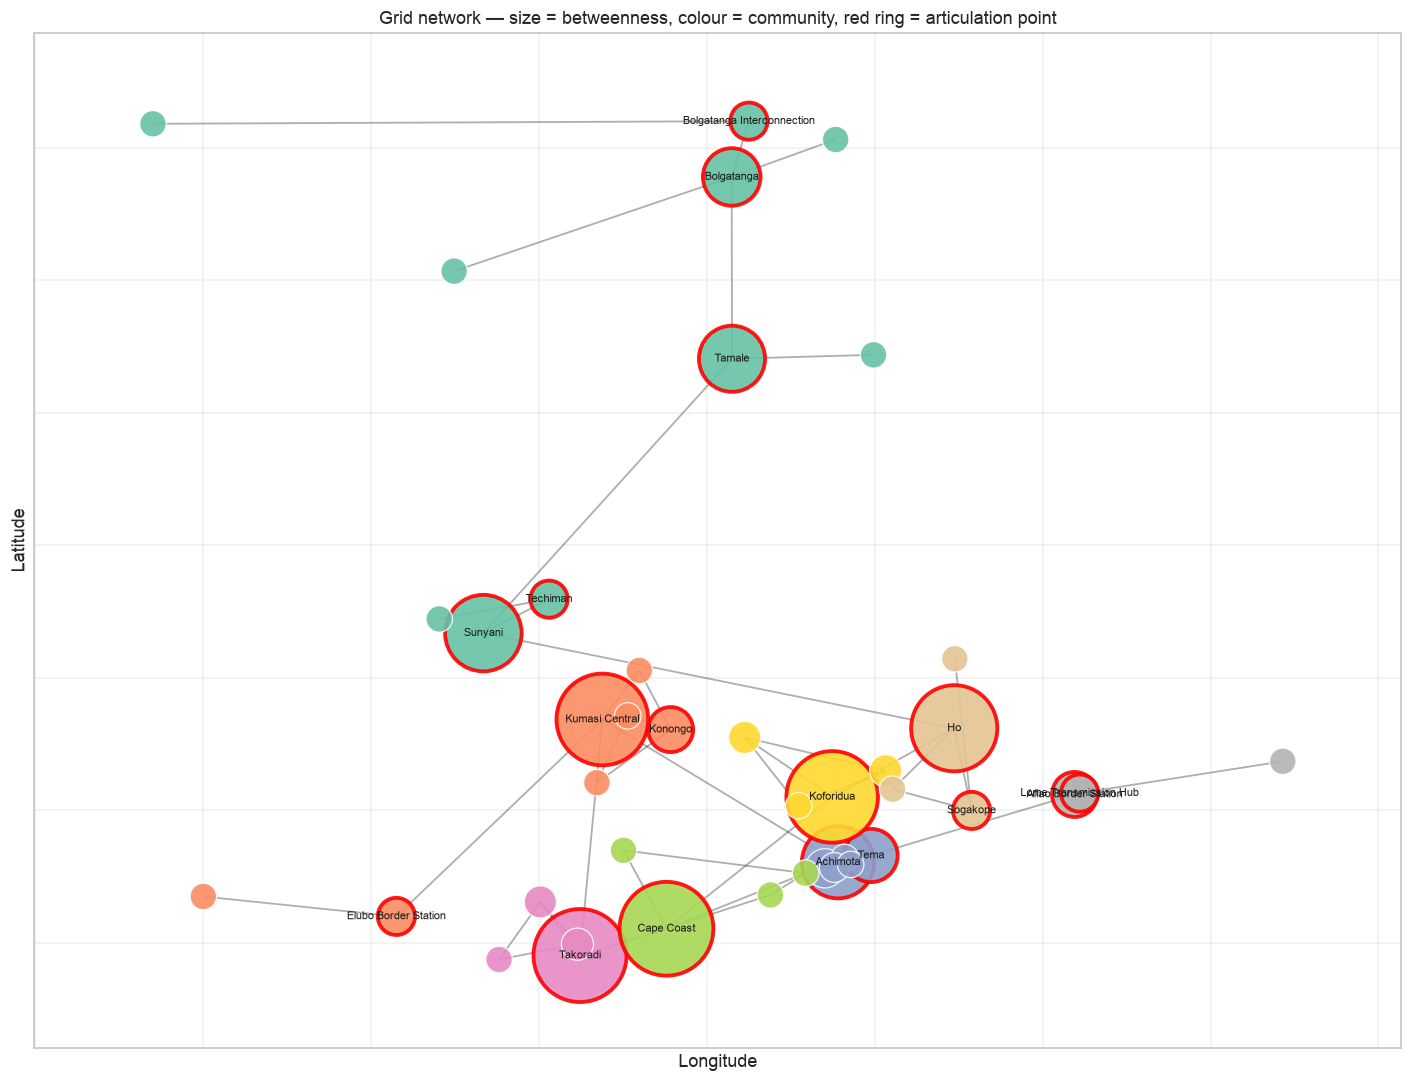

In [12]:
fig, ax = plt.subplots(figsize=(13, 10))

pos = {n: (main.nodes[n]["lon"], main.nodes[n]["lat"]) for n in main.nodes}
community_colours = [membership[n] for n in main.nodes]
sizes = [300 + 6000 * centrality.loc[n, "Betweenness"] for n in main.nodes]

nx.draw_networkx_edges(main, pos, ax=ax, alpha=0.35, width=1.2)
nodes_artist = nx.draw_networkx_nodes(
    main, pos, ax=ax, node_size=sizes, node_color=community_colours,
    cmap=plt.cm.Set2, alpha=0.9,
)
nodes_artist.set_edgecolor(["red" if n in articulation else "white" for n in main.nodes])
nodes_artist.set_linewidth([2.5 if n in articulation else 0.8 for n in main.nodes])

label_nodes = set(centrality.nlargest(10, "Betweenness").index) | articulation
nx.draw_networkx_labels(
    main, pos, ax=ax, font_size=7,
    labels={n: n.replace(" Substation", "") for n in label_nodes},
)

ax.set_title("Grid network — size = betweenness, colour = community, red ring = articulation point")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT}/n2_network_map.png", bbox_inches="tight")

In [13]:
centrality.to_csv("../data/network_metrics.csv")
impact.to_csv("../data/n1_contingency.csv", index=False)
print("saved network_metrics.csv and n1_contingency.csv for the dashboard")

saved network_metrics.csv and n1_contingency.csv for the dashboard


## Findings, in one place

1. **One grid plus two orphans.** 42 of 44 substations form a single component;
   Conakry Hub and Savelugu have no lines at all in this dataset.
2. **Hubs and corridors are different things.** Degree crowns Mallam / Kumasi
   Central / Cape Coast; betweenness crowns the backbone chain. The overlap between
   the two lists is where the genuinely critical all-rounders sit.
3. **Communities are unions of adjacent regions**, with border stations folded into
   their Ghanaian neighbours.
4. **Inter-regional corridors are bridges.** Redundancy lives inside regions, not
   between them — the clearest investment signal in the whole analysis.
5. **N-1: degree can't predict the damage.** Mallam (degree 5) is safe to lose;
   Cape Coast (also degree 5) strands half the network. What matters is whether a
   node's links are redundant local mesh or a link in the only chain — which is
   what betweenness and the articulation-point analysis actually measure.

All of it structural, all of it synthetic data — reliability *proxies*, not
operational findings about Ghana.